In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import itertools

from models import SourceEncoder, TargetEncoder

In [2]:
# Load the tensors
x_cat_tensor = torch.load('../dataset/processed/train_x_cat_tensor.pt')
x_ratio_tensor = torch.load('../dataset/processed/train_x_ratio_tensor.pt')
categorical_cardinalities = torch.load('../dataset/processed/train_cardinalities.pt').tolist()
labels_tensor = torch.load('../dataset/processed/train_labels_tensor.pt')

print("데이터 로드 완료:", x_cat_tensor.shape, ",", x_ratio_tensor.shape, ",", len(categorical_cardinalities))

데이터 로드 완료: torch.Size([13207, 23]) , torch.Size([13207, 4]) , 23


In [3]:
# Define PyTorch DataLoader
class UserDataset(Dataset):
    def __init__(self, x_cat_tensor, x_ratio_tensor, labels_tensor):
        self.x_cat = x_cat_tensor
        self.x_ratio = x_ratio_tensor
        self.labels = labels_tensor
        
    def __len__(self):
        return len(self.x_cat)
        
    def __getitem__(self, idx):
        # 비금융 데이터, 금융 데이터, 5단계 라벨을 함께 반환
        return self.x_cat[idx], self.x_ratio[idx], self.labels[idx]

# Create Dataset and DataLoader with the preprocessed tensors
dataset = UserDataset(x_cat_tensor, x_ratio_tensor, labels_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True) # Batch size is adjustable

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def symmetric_supcon_loss(z_NF, z_F, labels, temperature=0.1):
    """
    양방향(Symmetric) Supervised Contrastive Learning Loss
    비금융 -> 금융, 금융 -> 비금융 양쪽 방향의 정렬을 모두 최적화
    """
        
    # 1. 코사인 유사도 계산을 위한 L2 정규화
    z_NF = F.normalize(z_NF, dim=1)
    z_F = F.normalize(z_F, dim=1)
    
    # 2. 정답 마스크(Mask) 생성: 라벨이 같으면 1, 다르면 0
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    
    mask_sum = mask.sum(dim=1)
    mask_sum = torch.max(mask_sum, torch.ones_like(mask_sum)) # 0 나누기 방지
    
    # 3. 비금융(NF) -> 금융(F) 방향
    sim_NF_F = torch.matmul(z_NF, z_F.T) / temperature
    log_prob_NF_F = F.log_softmax(sim_NF_F, dim=1)
    loss_NF_F = -((mask * log_prob_NF_F).sum(dim=1) / mask_sum).mean()

    # 4. 금융(F) -> 비금융(NF) 방향 (Symmetric)
    sim_F_NF = torch.matmul(z_F, z_NF.T) / temperature
    log_prob_F_NF = F.log_softmax(sim_F_NF, dim=1)
    loss_F_NF = -((mask * log_prob_F_NF).sum(dim=1) / mask_sum).mean()
    
    # 5. 양방향 Loss의 평균 반환
    return (loss_NF_F + loss_F_NF) / 2.0


In [5]:
# 하이퍼파라미터 및 Early Stopping 설정

param_grid = {
    'batch_size': [256], # 256, 512, 1024
    'learning_rate': [1e-3], # 1e-3, 1e-4, 5e-5
    'temperature': [0.1], # 0.05, 0.1, 0.5
    'output_dim': [256], # 64, 128, 256
    'epochs': [300] # 100, 200
}

PATIENCE = 15       
MIN_DELTA = 0.001   

keys = param_grid.keys()
values = param_grid.values()
combinations = list(itertools.product(*values))

print(f"총 {len(combinations)}개의 조합을 탐색합니다. (Device: {device})")
print(f"조기 종료 조건: {PATIENCE} Epochs 동안 Loss 개선이 {MIN_DELTA} 미만일 경우 중단\n")

# Grid Search 루프 실행

best_overall_loss = float('inf')
best_params = None

# unpack 순서를 param_grid의 key 순서와 동일하게 맞춤
for idx, (batch_size, lr, temp, out_dim, num_epochs) in enumerate(combinations):
    print(f"[{idx+1}/{len(combinations)}] Testing -> Batch: {batch_size}, LR: {lr}, Temp: {temp}, Dim: {out_dim}, Max Epochs: {num_epochs}")
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # 모델 초기화 시 out_dim 변수를 적용
    source_encoder = SourceEncoder(categorical_cardinalities, embed_dim=16, output_dim=out_dim).to(device)
    target_encoder = TargetEncoder(input_dim=4, output_dim=out_dim).to(device)
    
    optimizer = optim.Adam(list(source_encoder.parameters()) + list(target_encoder.parameters()), lr=lr)
    
    best_epoch_loss = float('inf')
    epochs_no_improve = 0
    final_loss = float('inf')
    
    for epoch in range(num_epochs):
        source_encoder.train()
        target_encoder.train()
        
        total_loss = 0.0
        for batch_x_cat, batch_x_ratio, batch_labels in dataloader:
            batch_x_cat = batch_x_cat.to(device)
            batch_x_ratio = batch_x_ratio.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            
            # 💡 수정된 부분: 두 인코더 모두 첫 번째 리턴값(h)은 버리고 두 번째(z)만 가져옵니다!
            _, z_NF = source_encoder(batch_x_cat)
            _, z_F = target_encoder(batch_x_ratio)
            
            # 이제 z_NF와 z_F 모두 64차원의 텐서이므로 에러 없이 깔끔하게 계산됩니다.
            loss = symmetric_supcon_loss(z_NF, z_F, batch_labels, temperature=temp)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        
        if avg_loss < best_epoch_loss - MIN_DELTA:
            best_epoch_loss = avg_loss
            epochs_no_improve = 0 
        else:
            epochs_no_improve += 1 
            
        if (epoch + 1) % 10 == 0:
            print(f"  - Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} (No improve: {epochs_no_improve}/{PATIENCE})")
            
        if epochs_no_improve >= PATIENCE:
            print(f"  Early Stopping - (Epoch {epoch+1}): 더 이상 학습이 진전되지 않습니다.")
            final_loss = best_epoch_loss
            break
            
        if epoch == num_epochs - 1:
            final_loss = avg_loss
            
    # 최고 성능 기록 및 모델 저장
    if final_loss < best_overall_loss:
        best_overall_loss = final_loss
        best_params = {
            'batch_size': batch_size, 
            'learning_rate': lr, 
            'temperature': temp, 
            'output_dim': out_dim,
            'epochs_run': epoch + 1
        }
        print(f"  ★ New Best Loss 갱신! : {best_overall_loss:.4f}\n")
        
        torch.save(source_encoder.state_dict(), '../checkpoints/best_source_encoder.pth')
        torch.save(target_encoder.state_dict(), '../checkpoints/best_target_encoder.pth')
    else:
        print("\n") 

print(f"Grid Search 완료")
print(f"Best Loss: {best_overall_loss:.4f}")
print(f"Best Parameters: {best_params}")

총 1개의 조합을 탐색합니다. (Device: cpu)
조기 종료 조건: 15 Epochs 동안 Loss 개선이 0.001 미만일 경우 중단

[1/1] Testing -> Batch: 256, LR: 0.001, Temp: 0.1, Dim: 256, Max Epochs: 300
  - Epoch [10/300] Loss: 5.5168 (No improve: 1/15)
  - Epoch [20/300] Loss: 5.5068 (No improve: 0/15)
  - Epoch [30/300] Loss: 5.4954 (No improve: 0/15)
  - Epoch [40/300] Loss: 5.4850 (No improve: 1/15)
  - Epoch [50/300] Loss: 5.4726 (No improve: 0/15)
  - Epoch [60/300] Loss: 5.4653 (No improve: 1/15)
  - Epoch [70/300] Loss: 5.4589 (No improve: 4/15)
  - Epoch [80/300] Loss: 5.4495 (No improve: 0/15)
  - Epoch [90/300] Loss: 5.4397 (No improve: 0/15)
  - Epoch [100/300] Loss: 5.4358 (No improve: 0/15)
  - Epoch [110/300] Loss: 5.4329 (No improve: 1/15)
  - Epoch [120/300] Loss: 5.4276 (No improve: 4/15)
  - Epoch [130/300] Loss: 5.4229 (No improve: 0/15)
  - Epoch [140/300] Loss: 5.4190 (No improve: 1/15)
  - Epoch [150/300] Loss: 5.4164 (No improve: 4/15)
  - Epoch [160/300] Loss: 5.4129 (No improve: 5/15)
  - Epoch [170/300] 

### 시각화 및 유사도 검증

In [ ]:
# 1. 평가 모드 전환 및 전체 임베딩 추출
source_encoder.eval()
all_h_NF = []
all_z_NF = []
all_labels = []

print("비금융 데이터(h_NF, z_NF) 임베딩 추출 중...")
with torch.no_grad():
    for batch_x_cat, _, batch_labels in dataloader:
        h_NF, z_NF = source_encoder(batch_x_cat)
        all_h_NF.append(h_NF.cpu())
        all_z_NF.append(z_NF.cpu())
        all_labels.append(batch_labels.cpu())

all_h_NF = torch.stack(all_h_NF)
all_z_NF = torch.stack(all_z_NF)
all_labels = torch.stack(all_labels)

# 코사인 유사도 계산을 위해 L2 정규화 (크기를 1로 맞춤)
all_z_NF = F.normalize(all_z_NF, dim=1)

# 2. 특정 라벨을 가진 유저들의 인덱스 찾기
# (0: 매우 보수적, 4: 매우 공격적)
idx_class_4 = (all_labels == 4).nonzero(as_tuple=True)[0]
idx_class_0 = (all_labels == 0).nonzero(as_tuple=True)[0]

print(f"5단계(매우 공격적) 유저 수: {len(idx_class_4)}")
print(f"1단계(매우 보수적) 유저 수: {len(idx_class_0)}")

# 3. 샘플 유저 선택 및 코사인 유사도 비교
if len(idx_class_4) >= 2 and len(idx_class_0) >= 1:
    user_A = all_z_NF[idx_class_4[0]].unsqueeze(0) # 5단계 유저 A
    user_B = all_z_NF[idx_class_4[1]].unsqueeze(0) # 5단계 유저 B
    user_C = all_z_NF[idx_class_0[0]].unsqueeze(0) # 1단계 유저 C

    # 유사도 계산 (1에 가까울수록 똑같음, 0에 가까울수록 관계없음, -1은 정반대)
    sim_same = F.cosine_similarity(user_A, user_B).item()
    sim_diff = F.cosine_similarity(user_A, user_C).item()

    print("\n[ 코사인 유사도 검증 결과 ]")
    print(f"✅ 같은 5단계 유저끼리의 유사도 (User A vs B): {sim_same:.4f}")
    print(f"❌ 5단계 vs 1단계 유저의 유사도 (User A vs C): {sim_diff:.4f}")
else:
    print("특정 클래스의 유저 수가 부족하여 비교할 수 없습니다. 라벨 분포를 확인해주세요.")

비금융 데이터(z_NF) 임베딩 추출 중...
5단계(매우 공격적) 유저 수: 2030
1단계(매우 보수적) 유저 수: 4596

[ 코사인 유사도 검증 결과 ]
✅ 같은 5단계 유저끼리의 유사도 (User A vs B): 0.2834
❌ 5단계 vs 1단계 유저의 유사도 (User A vs C): -0.1364


t-SNE 차원 축소 진행 중 (데이터량에 따라 1~2분 소요될 수 있습니다)...


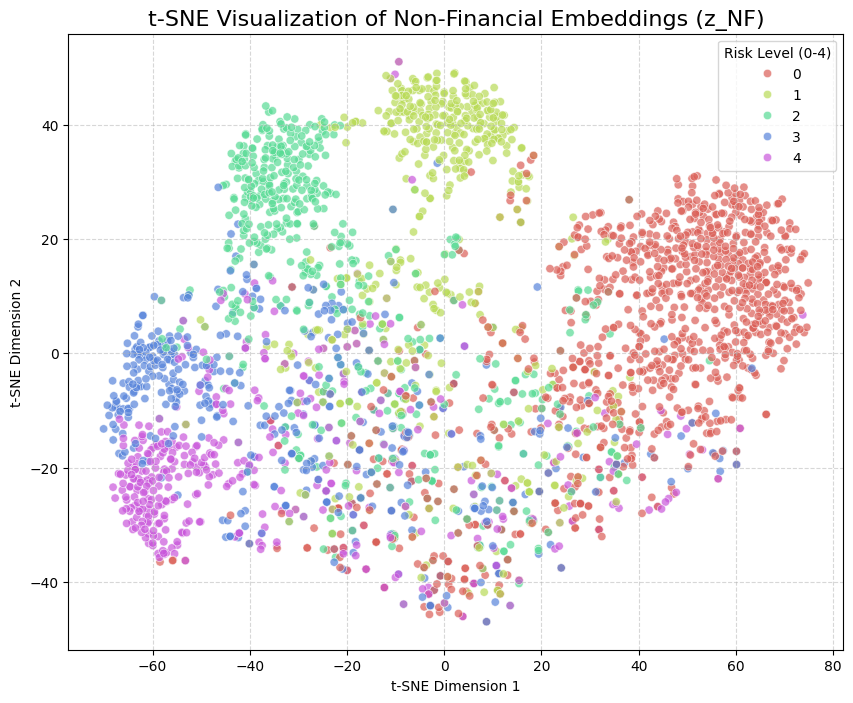

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

print("t-SNE 차원 축소 진행 중 (데이터량에 따라 1~2분 소요될 수 있습니다)...")

sample_size = len(all_z_NF)
indices = torch.randperm(len(all_z_NF))[:sample_size]

sampled_z_NF = np.array(all_z_NF[indices].cpu().tolist())
sampled_labels = np.array(all_labels[indices].cpu().tolist())

# 128차원 -> 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_NF_2d = tsne.fit_transform(sampled_z_NF)

# DataFrame으로 변환 (Seaborn 시각화를 위함)
df_tsne = pd.DataFrame({
    'tsne_1': z_NF_2d[:, 0],
    'tsne_2': z_NF_2d[:, 1],
    'Risk Level': sampled_labels
})

# 시각화 설정
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Risk Level',
    palette=sns.color_palette("hls", len(np.unique(sampled_labels))),
    data=df_tsne,
    legend="full",
    alpha=0.7
)

plt.title("t-SNE Visualization of Non-Financial Embeddings (z_NF)", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Risk Level (0-4)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print("t-SNE 차원 축소 진행 중 (데이터량에 따라 1~2분 소요될 수 있습니다)...")

sample_size = len(all_h_NF)
indices = torch.randperm(len(all_h_NF))[:sample_size]

sampled_h_NF = np.array(all_h_NF[indices].cpu().tolist())
sampled_labels = np.array(all_labels[indices].cpu().tolist())

# 128차원 -> 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
h_NF_2d = tsne.fit_transform(sampled_h_NF)

# DataFrame으로 변환 (Seaborn 시각화를 위함)
df_tsne = pd.DataFrame({
    'tsne_1': h_NF_2d[:, 0],
    'tsne_2': h_NF_2d[:, 1],
    'Risk Level': sampled_labels
})

# 시각화 설정
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Risk Level',
    palette=sns.color_palette("hls", len(np.unique(sampled_labels))),
    data=df_tsne,
    legend="full",
    alpha=0.7
)

plt.title("t-SNE Visualization of Non-Financial Embeddings (h_NF)", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Risk Level (0-4)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()